In [1]:
from matplotlib import pyplot as plt
import numpy as np

import wandb

import pandas as pd

In [2]:
api = wandb.Api()

In [3]:
PROJECT = "p16i/xaikd-s52-revised-distillation"
EXPERIMENT_GROUP= "student-cifar-resnet18-sweep-lambda-layer"

In [8]:
def read_data_per_policy(
    teacher, student,
    dataset,
    policy_alias,

    verbose=False,
    return_raw = False,
    training_size=1.0,
    experiment_group=EXPERIMENT_GROUP,
    return_only_best=True
):
    
    if policy_alias in ["kd-only", "student-only"]:
        experiment_group = "student-cifar-resnet18-with-valset"
        
    if policy_alias == "kd-only":
        lambda_task = 0
        lambda_kd = 1
        policy = "nothing"
    elif policy_alias == "student-only":
        lambda_task = 1
        lambda_kd = 0
        policy = "nothing"
    else:
        lambda_task = 0
        lambda_kd = 1
        policy = policy_alias
            
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": experiment_group},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.lambda-task": lambda_task},
            {"config.lambda-kd": lambda_kd},
            {"config.training_size": training_size},
            {"config.policy": policy},
        ]}
    )
    
    if verbose:
        print(f"{policy_alias} we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "student_test_auroc"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        rows.append(
            dict(
                policy_alias=policy_alias,
                train_auroc=run.summary["train_auroc"],
                
                val_auroc=run.summary["best_val_auroc"], 
                test_auroc=run.summary["student_test_auroc"],
                teacher_auroc=run.summary["teacher_auroc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    assert df.shape[0] > 0
    
    df = df.groupby(by="lambda_layer").agg(
        {
            
            "policy_alias": ["first"],
            "lambda_task": ["first"],
            "lambda_kd": ["first"],
            "lambda_layer": ["first"],
            "teacher_auroc": ["mean", "max", "min"],
            "train_auroc": ["mean", "sem", "count"],
            "val_auroc": ["mean", "sem", "count"],
            "test_auroc": ["mean", "sem", "count"],

        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_auroc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
        
    if return_only_best:
        df = df[df["val_auroc"]["mean"].max() == df["val_auroc"]["mean"]]
        
    return df

read_data_per_policy(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    policy_alias="vkd",
    training_size=0.01,
    verbose=True,
#     return_only_best=False
)

vkd we have 21 runs
df.shape: (7, 17)


lambda_layer policy_alias lambda_task lambda_kd lambda_layer teacher_auroc  \
                      first       first     first        first          mean   
1         0.01          vkd           0         1         0.01           1.0   

          train_auroc            val_auroc                 test_auroc  \
  max min        mean  sem count      mean       sem count       mean   
1   1   1         1.0  0.0     3  0.691167  0.007694     3   0.682182   

                   
        sem count  
1  0.012022     3

In [5]:
def read_data(arr_policies, **kwargs):
    arr_dfs = []

    for policy in arr_policies:
        arr_dfs.append(
            read_data_per_policy(
                policy_alias=policy,
                **kwargs,
            )
        )
    return pd.concat(arr_dfs)

read_data(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    arr_policies=[
#         "kd-only",
        "vid",
        "attention-transfer",
        "basis-bn:prcaposdef"
    ],
    training_size=1.0,
    verbose=True,
)

vid we have 21 runs
df.shape: (7, 17)
attention-transfer we have 21 runs
df.shape: (7, 17)
basis-bn:prcaposdef we have 21 runs
df.shape: (7, 17)


lambda_layer         policy_alias lambda_task lambda_kd lambda_layer  \
                              first       first     first        first   
4         10.0                  vid           0         1         10.0   
6       1000.0   attention-transfer           0         1       1000.0   
5        100.0  basis-bn:prcaposdef           0         1        100.0   

  teacher_auroc         train_auroc                 val_auroc                  \
           mean max min        mean       sem count      mean       sem count   
4           1.0   1   1    0.982066  0.000975     3  0.981735  0.001716     3   
6           1.0   1   1    0.994918  0.000734     3  0.984540  0.002341     3   
5           1.0   1   1    0.979772  0.000979     3  0.984091  0.001581     3   

  test_auroc                  
        mean       sem count  
4   0.978723  0.001249     3  
6   0.984154  0.001753     3  
5   0.978221  0.003109     3

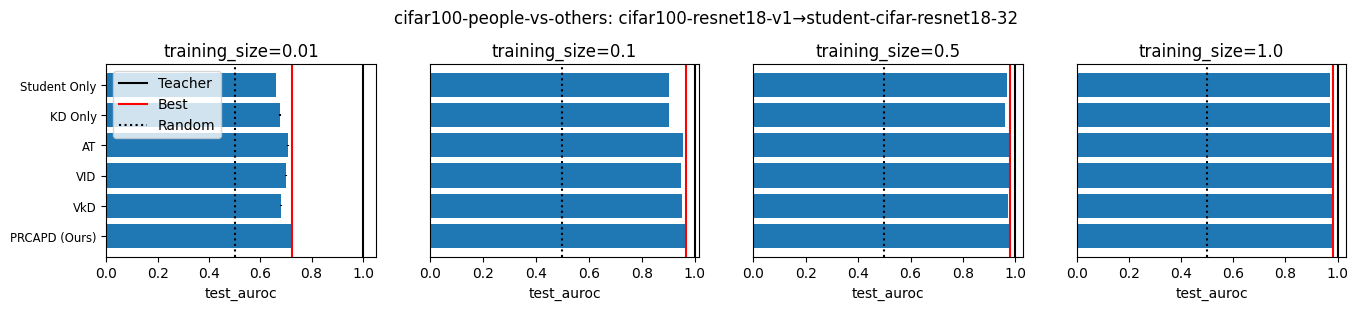

In [10]:
def _alias_policy(name):
    return {
        "student-only": "Student Only",
        "kd-only": "KD Only",
        "vid": "VID",
        "attention-transfer": "AT",
        "vkd": "VkD",
        "basis-bn:pca": "PCA (Ours)",
        "basis-bn:gradpca": "GPCA (Ours)",
        "basis-bn:prcaposdef": "PRCAPD (Ours)",
    }[name]

def viz(
    dataset_name,
    teacher, student, 
    arr_training_sizes=[
        0.01,
        0.1,  
        0.5,
        1.0
    ],
    arr_policies=[
        "student-only",
        "kd-only",
        "attention-transfer",
        "vid",
        "vkd",
        "basis-bn:prcaposdef",
    ]
):
    
    nrows = 1
    ncols = len(arr_training_sizes)
    
    plt.figure(figsize=(4*ncols, 2.5 * nrows))
    
    plt.suptitle(f"{dataset_name}: {teacher}→{student}", y=1.1)
    
    metric_name = "test_auroc"
    
    xticks = np.arange(len(arr_policies))
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(1, ncols, tix +1)

        plt.title(f"training_size={training_size}")
        
        

#         return df
    
#         assert df.shape[0] == len(arr_policies)
        
        arr_means = np.zeros(len(arr_policies))
        arr_sems = np.zeros(len(arr_policies))
        
        for pix, policy in enumerate(arr_policies):

            _df = read_data_per_policy(
                teacher=teacher,
                student=student,
                dataset=dataset_name,
                policy_alias=policy,
                training_size=training_size,
            )

            assert _df.shape[0] == 1
            assert (_df[metric_name]["count"].values == 3).all()
            value = _df[metric_name]["mean"].values[0]
            arr_means[pix] = value
            arr_sems[pix] = _df[metric_name]["sem"].values[0]
            
        
        teacher_value = _df.teacher_auroc["mean"].values[-1]
        
        
        plt.barh(
            xticks,
            arr_means,
            yerr=arr_sems
        )
    
        plt.axvline(teacher_value, ls="-", color="k", label="Teacher")
        
        plt.axvline(np.max(arr_means), color="r", ls="-", label="Best")

        plt.axvline(0.5, ls=":", color="k", label="Random")
        
        plt.xlabel(metric_name)
        plt.gca().invert_yaxis()
        
        if tix == 0:
            
            plt.yticks(
                xticks, 
                list(map(lambda n: _alias_policy(n), arr_policies)),
                fontsize="small"
            )
            plt.legend()
        else:
            plt.yticks([])
        
        
        
viz(
    dataset_name="cifar100-people-vs-others",
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32"
)